# Video Object Segmentation & Evaluation with HideAndSeg 🐙

This notebook demonstrates how to initialize the **HideAndSeg** pipeline, execute automated tracking using YOLO bounding boxes combined with SAM 2 propagation, and examine the integrated metric diagnostics.

Let's start by importing the HideAndSeg class from the hideandseg module.

In [1]:
from hideandseg import HideAndSeg

Let's initialize the `HideAndSeg` class. You can configure it using the following parameters for the SAM and YOLO models:

* `sam2_model_size`: Specifies the size of the SAM 2 model to use (e.g., `"tiny"`, `"small"`, `"base"`, or `"large"`).

**Optional Parameters:**
* `sam2_checkpoint_path`: The directory path where the SAM 2 checkpoints will be saved. Modify this if you already have the weights downloaded elsewhere.
* `yolo_weights`: The path to the YOLO weights file. Update this if you are using a custom-trained YOLO object detection model.

In [2]:
hands = HideAndSeg(
    sam2_model_size="large"
)

[INFO] Initializing HideAndSeg pipeline...
[INFO] Running inference on device: cuda
[INFO] Verifying SAM2 checkpoint...


[SUCCESS] HideAndSeg pipeline initialized successfully.


Now, use the `segment` method to process the video. Make sure to replace the `video_path` and `output_path` with the actual file paths on your system. 

* `n_annotated_frames`: Specifies how many frames will use YOLO detection as a prompt for SAM 2. 

> 💡 **Tip:** Increase this value if the target object is frequently occluded (hidden) throughout the video. Keep in mind that a higher number of annotated frames will increase the overall processing time.

In [3]:
hands.segment(
    video_path="video_example.mp4",
    output_path="output",
    n_annotated_frames=5,
)

[INFO] Step 1/4: Extracting video frames...
[SUCCESS] Successfully extracted 207 frames.
[INFO] Step 2/4: Initializing SAM2 engine state...
[INFO] Step 3/4: Generating object annotations on 5 keyframes...


  -> Keyframe 0 annotated successfully.
[INFO] Step 4/4: Propagating segmentation masks throughout the video...
  -> Keyframe 51 annotated successfully.
[INFO] Step 4/4: Propagating segmentation masks throughout the video...
  -> Keyframe 103 annotated successfully.
[INFO] Step 4/4: Propagating segmentation masks throughout the video...
  -> Keyframe 154 annotated successfully.
[INFO] Step 4/4: Propagating segmentation masks throughout the video...
  -> Keyframe 206 annotated successfully.
[INFO] Step 4/4: Propagating segmentation masks throughout the video...


propagate in video: 100%|█████████████████████████████████████████████████████████████| 207/207 [14:44<00:00,  4.27s/it]


[SUCCESS] Video propagation completed.
[INFO] SAM2 state cleaned up. Process finished.

══════════════════════════════════════════════════════════════════════
                SEGMENTATION QUALITY EVALUATION REPORT                
══════════════════════════════════════════════════════════════════════
 Total Tracked Timeline Length  : 207 frames
 Segmentation Coverage          : 100.00% (207/207 frames)
──────────────────────────────────────────────────────────────────────
 METRIC DISTRIBUTION ANALYSIS:
──────────────────────────────────────────────────────────────────────
  [DICE(t)]
    │  High Stability     (1.0 - 0.9) :  68.12%  (141 frames)
    │  Moderate Drift     (0.9 - 0.75):  28.02%  (58 frames)
    │  Stability Warning  (< 0.75)    :   0.00%  (0 frames)
  [NC(t)]
    │  Stable Geometry     (1 - 2)    :  97.10%  (201 frames)
    │  Minor Fragmentation (3 - 5)    :   2.42%  (5 frames)
    │  Disruption Warning  (5+)       :   0.00%  (0 frames)
───────────────────────────────────

### Success! 🎉

As shown in the execution output, **HideAndSeg** automatically segments the video and generates a summary report. 

If the process fails or certain segments exhibit poor segmentation quality, the pipeline will flag those specific video sections. You can then rerun the pipeline with adjusted configurations, such as increasing the model size or the number of `n_annotated_frames`.

### Output Structure

`HideAndSeg` generates multiple output files organized as follows:

* `output/frames/`: Contains the extracted individual frames from the source video.
* `output/masks/`: Contains the predicted binary segmentation masks corresponding to each frame.

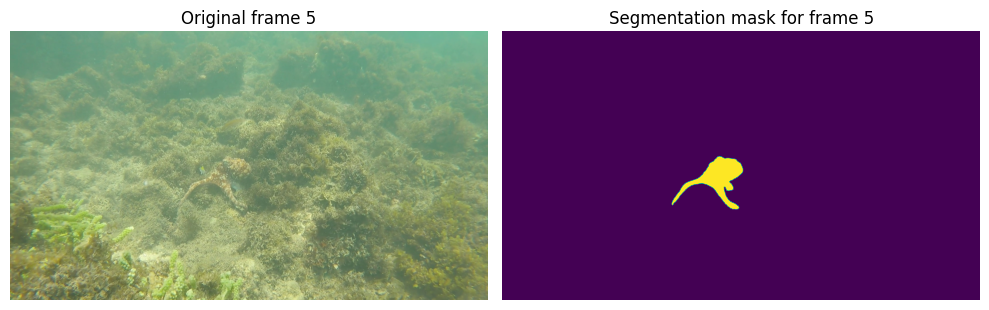

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

img1 = Image.open("output/frames/00005.jpg")
img2 = Image.open("output/masks/00005.bmp")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1)
axes[0].axis("off")
axes[0].set_title("Original frame 5")

axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("Segmentation mask for frame 5")

plt.tight_layout()
plt.show()

* `output/masked_frames/`: Contains the cropped images of the target object (e.g., the octopus) with the segmentation mask applied.

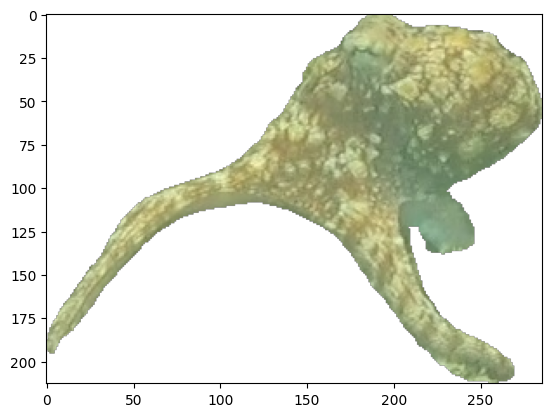

In [5]:
img3 = Image.open("output/masked_frames/00005.png")
plt.imshow(img3)

* `output/segmentation_quality_metrics.csv`: A CSV file containing the computed segmentation quality metrics evaluated for each frame.

In [6]:
import pandas as pd
pd.read_csv('output/segmentation_quality_metrics.csv').head()

,frame,dice,nc
0,0,1.000000,NaN
1,1,0.965010,1.0
2,2,0.970808,1.0
3,3,0.961083,1.0
4,4,0.919176,1.0


### Video Compilation

Finally, if you want to combine all the generated outputs into a single video file, you can use the `compile_video` function. 

This function creates a final video that overlays the predicted segmentation masks onto the original frames, alongside a dynamic dashboard displaying the calculated metrics in real time for each frame.

In [7]:
from hideandseg import compile_video

compile_video(framerate=30, output_path="output")

[INFO] Initializing video compilation at 30 FPS...


[INFO] Rendering Frames: 100%|█████████████████████████████████████████████████████| 207/207 [00:31<00:00,  6.49frame/s]



[SUCCESS] Compilation complete! Video saved to: output/segmented_video.mp4
